Used libraries

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Showing Dataset Information

In [73]:
df = pd.read_excel('default of credit card clients.xls')
print(df.head())

  Unnamed: 0         X1   X2         X3        X4   X5     X6     X7     X8  \
0         ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3   
1          1      20000    2          2         1   24      2      2     -1   
2          2     120000    2          2         2   26     -1      2      0   
3          3      90000    2          2         2   34      0      0      0   
4          4      50000    2          2         1   37      0      0      0   

      X9  ...        X15        X16        X17       X18       X19       X20  \
0  PAY_4  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3   
1     -1  ...          0          0          0         0       689         0   
2      0  ...       3272       3455       3261         0      1000      1000   
3      0  ...      14331      14948      15549      1518      1500      1000   
4      0  ...      28314      28959      29547      2000      2019      1200   

        X21       X22       X23             

Data Cleaning

In [74]:
df.iloc[0]

Unnamed: 0                            ID
X1                             LIMIT_BAL
X2                                   SEX
X3                             EDUCATION
X4                              MARRIAGE
X5                                   AGE
X6                                 PAY_0
X7                                 PAY_2
X8                                 PAY_3
X9                                 PAY_4
X10                                PAY_5
X11                                PAY_6
X12                            BILL_AMT1
X13                            BILL_AMT2
X14                            BILL_AMT3
X15                            BILL_AMT4
X16                            BILL_AMT5
X17                            BILL_AMT6
X18                             PAY_AMT1
X19                             PAY_AMT2
X20                             PAY_AMT3
X21                             PAY_AMT4
X22                             PAY_AMT5
X23                             PAY_AMT6
Y             de

In [75]:

df = df.apply(pd.to_numeric, errors='coerce')      #Convert all Object values to float64 values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  30000 non-null  float64
 1   X1          30000 non-null  float64
 2   X2          30000 non-null  float64
 3   X3          30000 non-null  float64
 4   X4          30000 non-null  float64
 5   X5          30000 non-null  float64
 6   X6          30000 non-null  float64
 7   X7          30000 non-null  float64
 8   X8          30000 non-null  float64
 9   X9          30000 non-null  float64
 10  X10         30000 non-null  float64
 11  X11         30000 non-null  float64
 12  X12         30000 non-null  float64
 13  X13         30000 non-null  float64
 14  X14         30000 non-null  float64
 15  X15         30000 non-null  float64
 16  X16         30000 non-null  float64
 17  X17         30000 non-null  float64
 18  X18         30000 non-null  float64
 19  X19         30000 non-null  float64


In [76]:
df.duplicated().sum()       #No duplicate data

np.int64(0)

In [77]:
df=df.drop(index=0,columns="Unnamed: 0")    #delete first row in data & the unnamed column
df.isnull().sum()

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
Y      0
dtype: int64

In [78]:
df.describe()
#X3 has 7 unique values and it should have only 4 (1,2,3,4)
#X4 has 4 unique values and it should have only 3 (1,2,3)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [79]:
df = df[df['X3'] != 6] 
df = df[df['X3'] != 5]
df = df[df['X3'] != 0]  

df['X3'].value_counts()   #removed all values (0,5,6)

X3
2.0    14030
1.0    10585
3.0     4917
4.0      123
Name: count, dtype: int64

In [80]:
df = df[df['X4'] != 0]

df['X4'].value_counts()     #removed all values (0)

X4
2.0    15806
1.0    13477
3.0      318
Name: count, dtype: int64

Dealing with Outliers

In [81]:
df['X5'].describe()  #Shows the Statistics of the Age feature
                     #Max Age is 79

count    29601.000000
mean        35.464072
std          9.213243
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: X5, dtype: float64

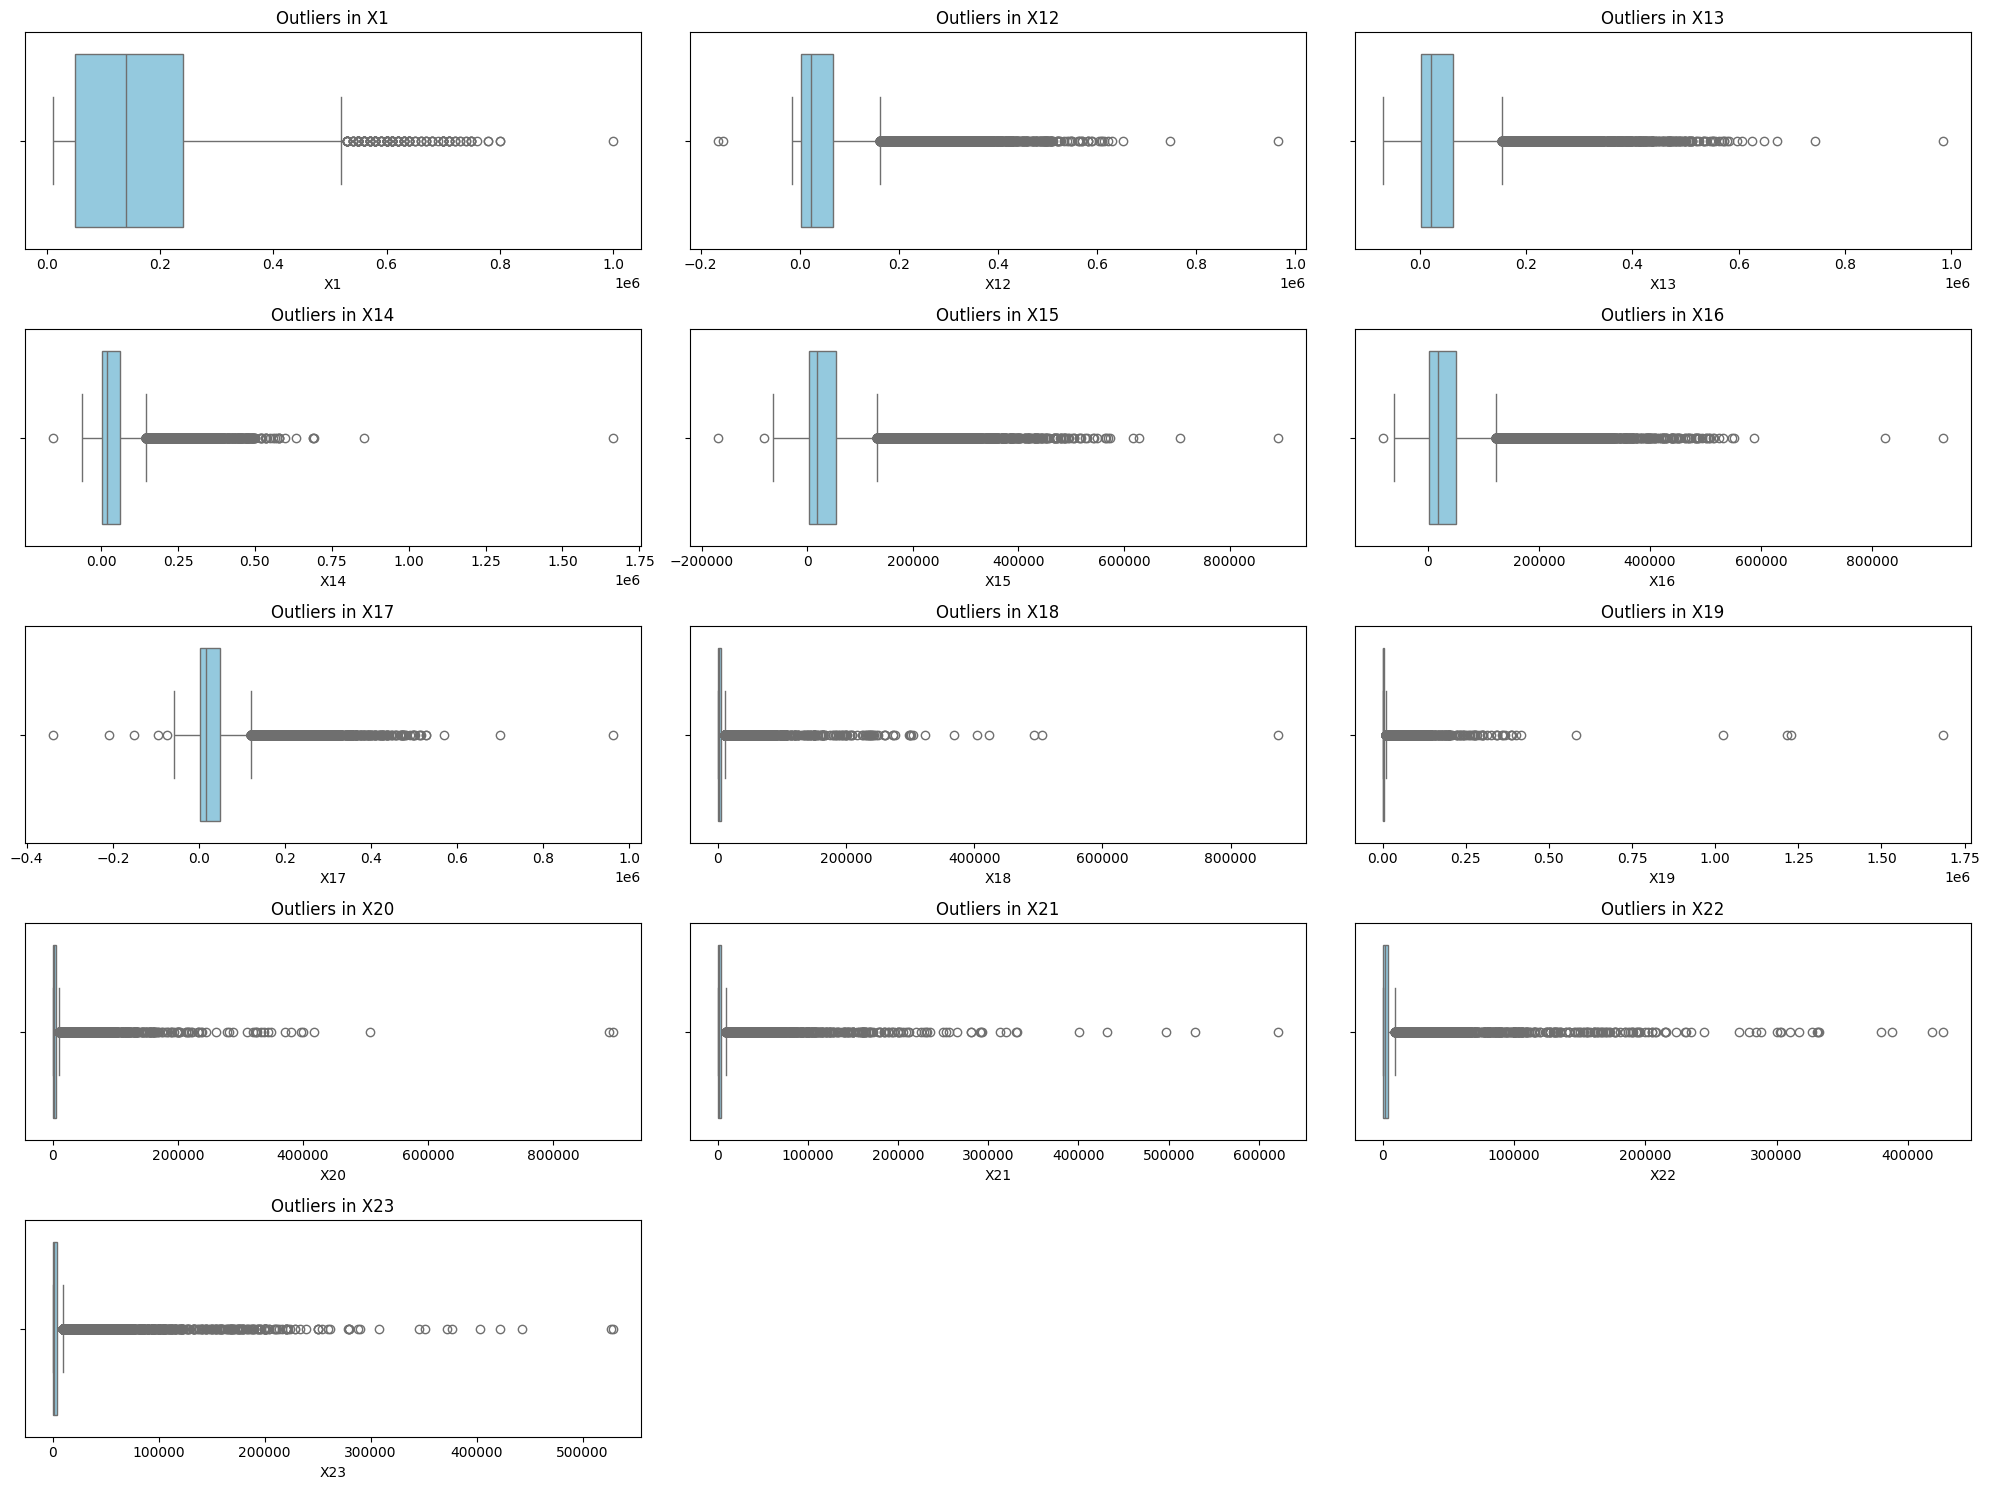

In [82]:
numeric_cols = ['X1','X12', 'X13', 'X14', 'X15', 'X16', 'X17', 
                'X18', 'X19', 'X20', 'X21', 'X22', 'X23']       #Select which column want to see the outliers of them

plt.figure(figsize=(20, 15))

for i, col in enumerate(numeric_cols):
    plt.subplot(5, 3, i+1) 
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')
    plt.tight_layout()


In [83]:
outlier_cols = [
    'X1',                        # LIMIT_BAL
    'X12', 'X13', 'X14', 'X15', 'X16', 'X17', # BILL_AMT1 to BILL_AMT6
    'X18', 'X19', 'X20', 'X21', 'X22', 'X23'  # PAY_AMT1 to PAY_AMT6
]
for col in outlier_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1


        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR


        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

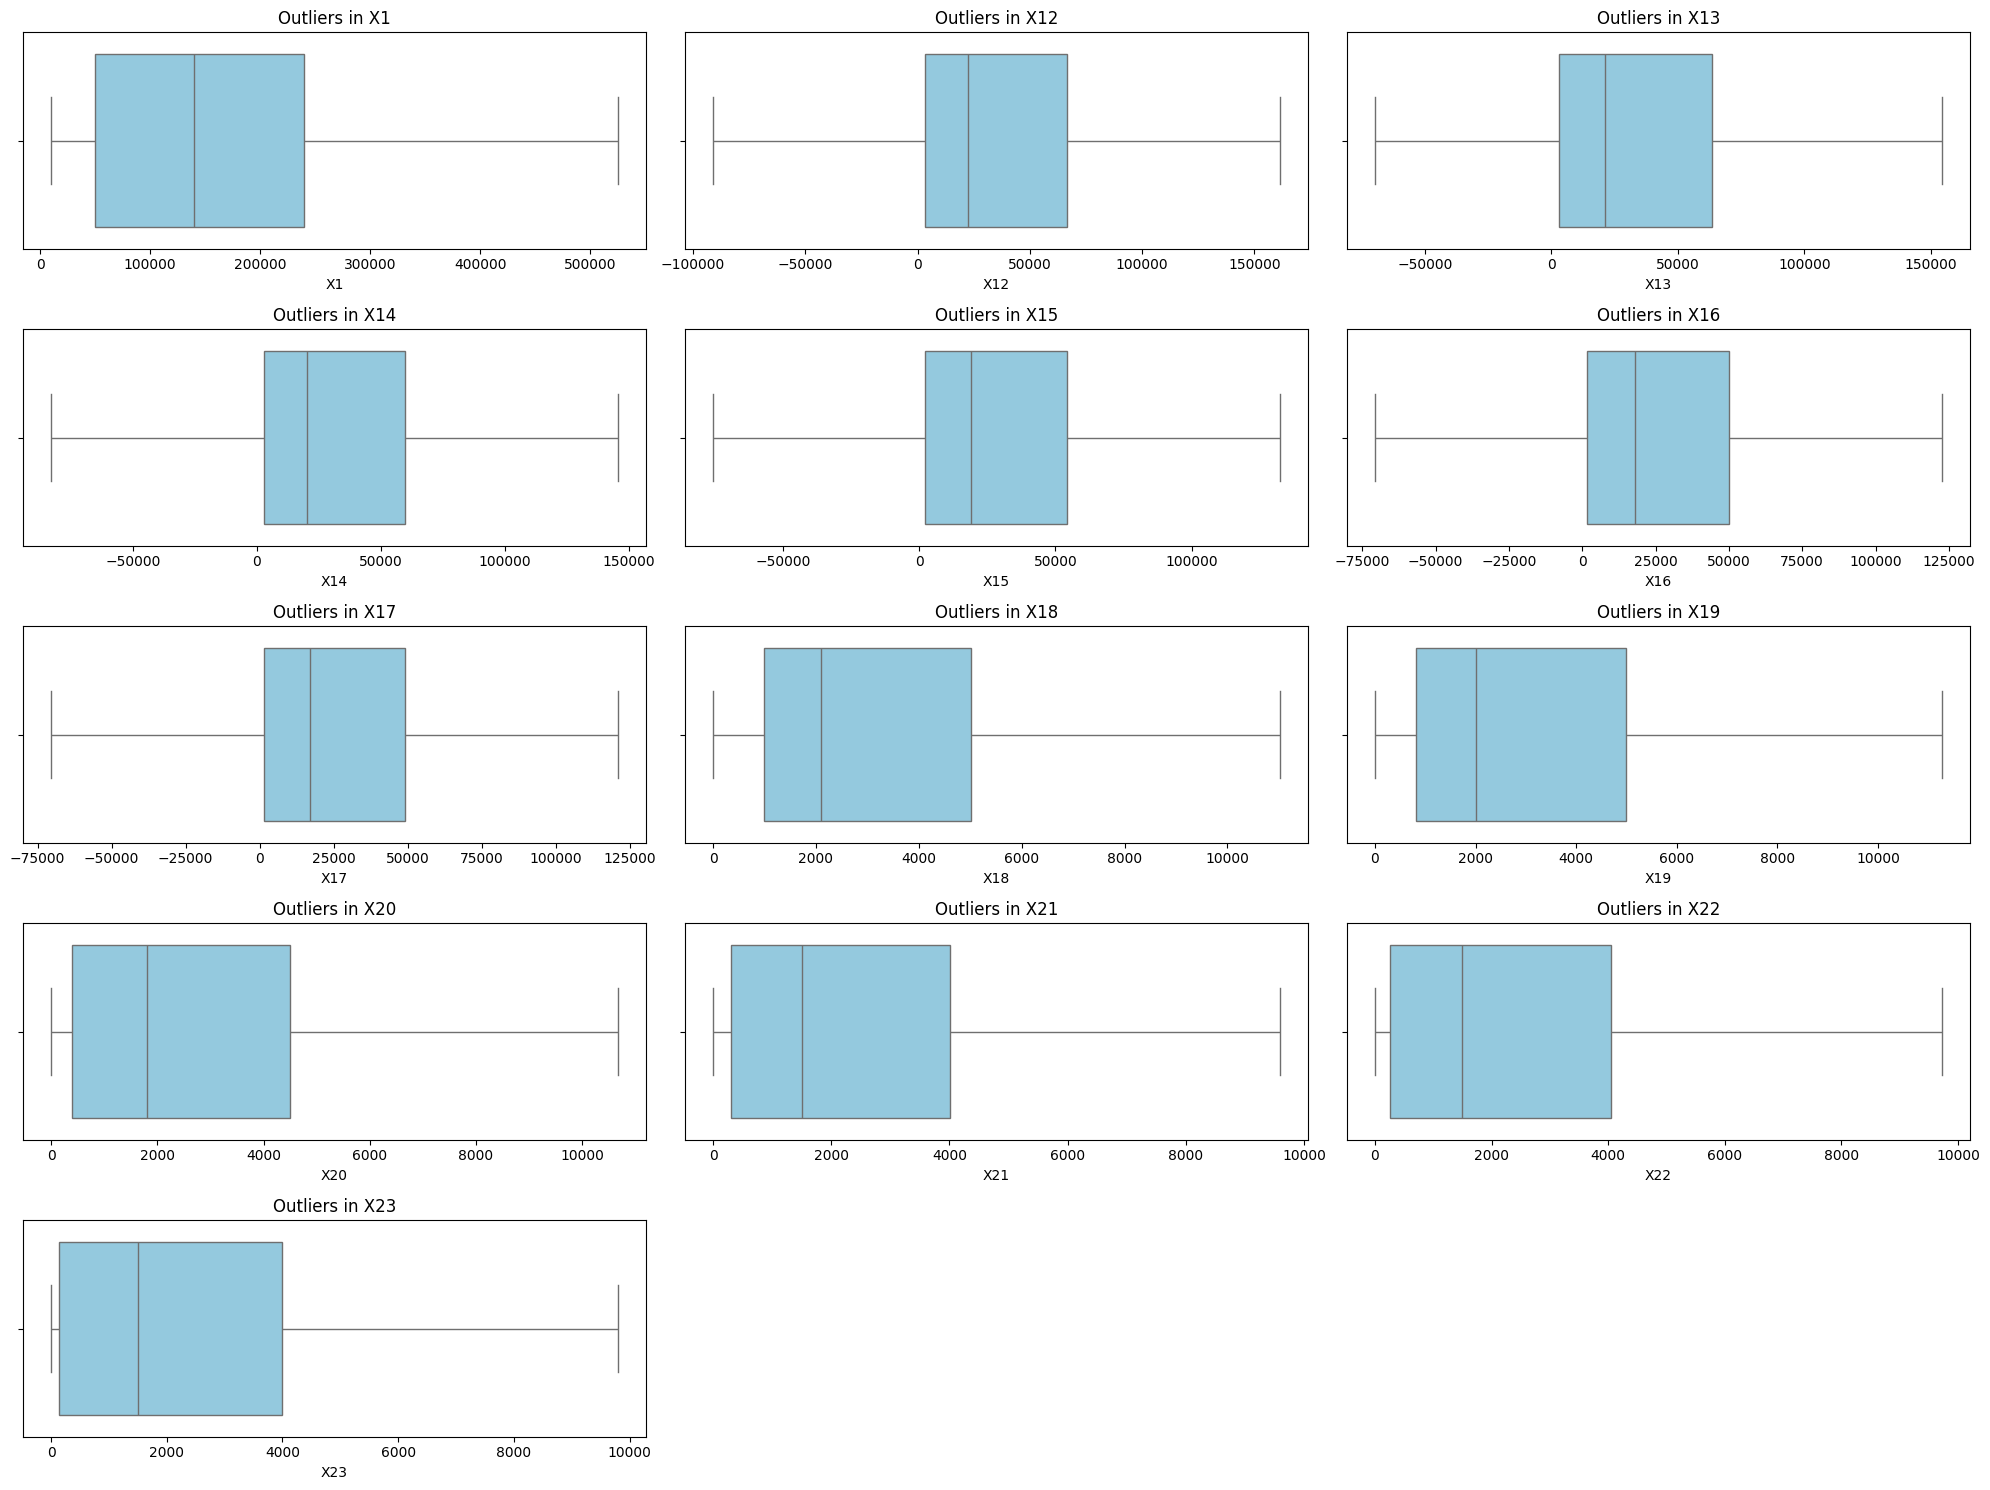

In [84]:


numeric_cols = ['X1', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 
                'X18', 'X19', 'X20', 'X21', 'X22', 'X23']

plt.figure(figsize=(20, 15))

for i, col in enumerate(numeric_cols):
    plt.subplot(5, 3, i+1) 
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')
    plt.tight_layout()



Encoding

In [85]:


#Columns to be mapped
mapping_edu = {1: 'GradSchool', 2: 'University', 3: 'HighSchool', 4: 'Others'}
mapping_mar = {1: 'Married', 2: 'Single', 3: 'Others'}
mapping_sex = {1: 'Male', 2: 'Female'}

# Mapping of selected columns
df['X2'] = df['X2'].map(mapping_sex)
df['X3'] = df['X3'].map(mapping_edu)
df['X4'] = df['X4'].map(mapping_mar)

#Applying One Hot encoding
df = pd.get_dummies(df, columns=['X2', 'X3', 'X4'], prefix=['Sex', 'Edu', 'Mar'], drop_first=True,dtype=float)

#See the new columns values
print("Columns in Dataset now:")
print(df.columns)

Columns in Dataset now:
Index(['X1', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14',
       'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y',
       'Sex_Male', 'Edu_HighSchool', 'Edu_Others', 'Edu_University',
       'Mar_Others', 'Mar_Single'],
      dtype='str')


EDA & Visualization 

In [86]:
df.shape

(29601, 27)

In [87]:
df.info()

<class 'pandas.DataFrame'>
Index: 29601 entries, 1 to 30000
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   X1              29601 non-null  float64
 1   X5              29601 non-null  float64
 2   X6              29601 non-null  float64
 3   X7              29601 non-null  float64
 4   X8              29601 non-null  float64
 5   X9              29601 non-null  float64
 6   X10             29601 non-null  float64
 7   X11             29601 non-null  float64
 8   X12             29601 non-null  float64
 9   X13             29601 non-null  float64
 10  X14             29601 non-null  float64
 11  X15             29601 non-null  float64
 12  X16             29601 non-null  float64
 13  X17             29601 non-null  float64
 14  X18             29601 non-null  float64
 15  X19             29601 non-null  float64
 16  X20             29601 non-null  float64
 17  X21             29601 non-null  float64
 18  X2

In [88]:
df.describe()

,X1,X5,X6,X7,X8,X9,X10,X11,X12,X13,...,X21,X22,X23,Y,Sex_Male,Edu_HighSchool,Edu_Others,Edu_University,Mar_Others,Mar_Single
count,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,...,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000
mean,167028.940914,35.464072,-0.014932,-0.131313,-0.163440,-0.218303,-0.263978,-0.287558,44004.554643,42124.003344,...,2718.360630,2735.957907,2713.009324,0.223134,0.396811,0.164623,0.004155,0.473768,0.010743,0.533968
std,128195.491191,9.213243,1.124503,1.199642,1.199793,1.172220,1.136217,1.152206,50946.023388,48909.338691,...,3073.590945,3098.985600,3124.167065,0.416355,0.489244,0.370846,0.064328,0.499320,0.103091,0.498853
min,10000.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-91114.500000,-69777.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3528.000000,2970.000000,...,298.000000,259.000000,138.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,140000.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22259.000000,21050.000000,...,1500.000000,1500.000000,1500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,240000.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,66623.000000,63497.000000,...,4014.000000,4042.000000,4000.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,525000.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,161265.500000,154287.500000,...,9588.000000,9716.500000,9793.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [89]:
#Class imbalance
df["Y"].value_counts(normalize=True)

Y
0.0    0.776866
1.0    0.223134
Name: proportion, dtype: float64

In [90]:
#dataset size
#no missing values
#class imbalance 22.32% y = 1 vs 77.68% y = 0 (approx)
#The target variable is imbalanced, with approximately 77.68% of clients not defaulting and 22.32% defaulting.
#This imbalance may affect model performance, as models could become biased toward the majority class

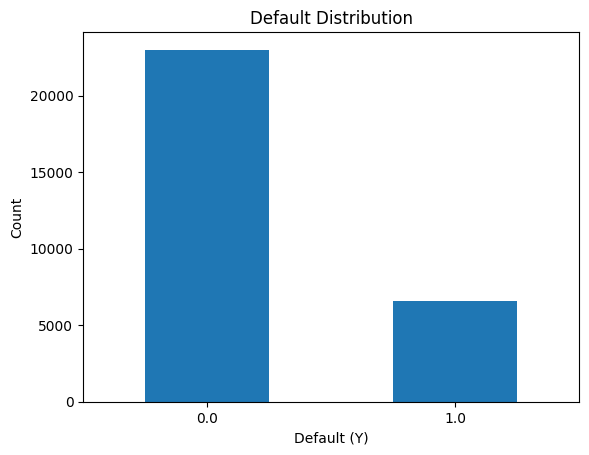

In [91]:
df["Y"].value_counts().plot(kind="bar")

plt.title("Default Distribution")
plt.xlabel("Default (Y)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

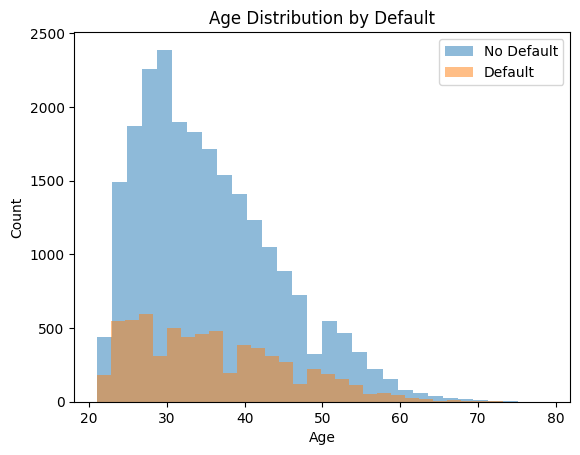

In [92]:
#Younger clients tend to have slightly higher default rates.
plt.hist(df[df["Y"] == 0]["X5"], bins=30, alpha=0.5, label="No Default")
plt.hist(df[df["Y"] == 1]["X5"], bins=30, alpha=0.5, label="Default")

plt.title("Age Distribution by Default")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()

C:\Users\M\AppData\Local\Temp\ipykernel_33816\3875997493.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_0, data_1], labels=["No Default", "Default"])


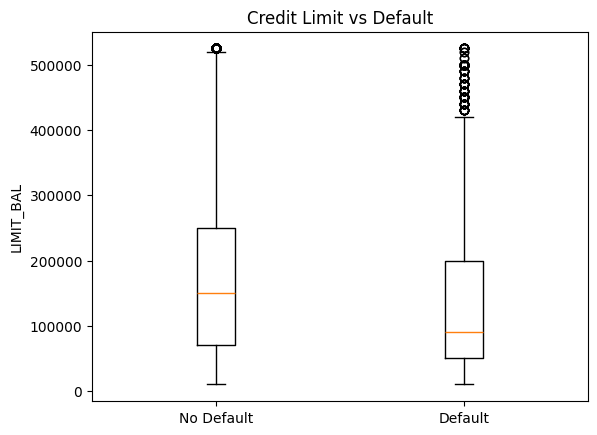

In [93]:
#Clients with lower credit limits are more likely to default.
data_0 = df[df["Y"] == 0]["X1"]
data_1 = df[df["Y"] == 1]["X1"]

plt.boxplot([data_0, data_1], labels=["No Default", "Default"])

plt.title("Credit Limit vs Default")
plt.ylabel("LIMIT_BAL")
plt.show()


Clients who did not default tend to have higher credit limits compared to those who defaulted. This suggests that customers with higher financial trust from the bank are less likely to fail in repayment
The boxplot shows that default behavior is associated with lower credit limits, while non-default clients tend to have higher and more stable credit limits. Additionally, the presence of outliers in the default group indicates higher variability in financial behavior among defaulters.

C:\Users\M\AppData\Local\Temp\ipykernel_33816\2273158750.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_0, data_1], labels=["No Default", "Default"])


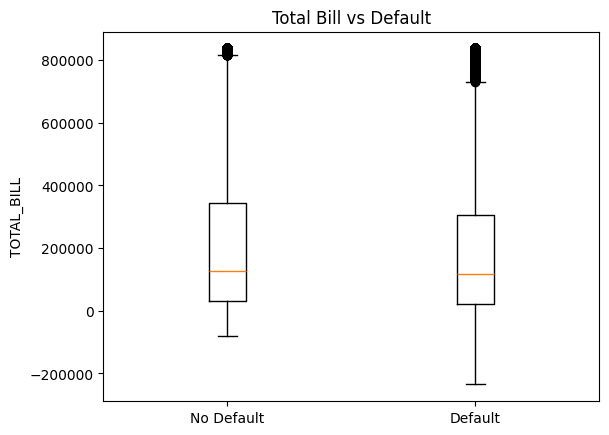

In [94]:
bill_cols = ["X12","X13","X14","X15","X16","X17"]

df["TOTAL_BILL"] = df[bill_cols].sum(axis=1)

data_0 = df[df["Y"] == 0]["TOTAL_BILL"]
data_1 = df[df["Y"] == 1]["TOTAL_BILL"]

plt.boxplot([data_0, data_1], labels=["No Default", "Default"])

plt.title("Total Bill vs Default")
plt.ylabel("TOTAL_BILL")
plt.show()

Clients with higher total billed amounts tend to show different repayment behavior, and higher financial exposure may be associated with increased risk.

C:\Users\M\AppData\Local\Temp\ipykernel_33816\3315417866.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_0, data_1], labels=["No Default", "Default"])


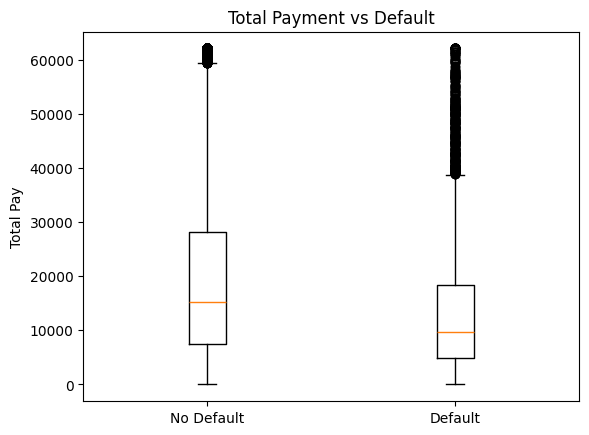

In [95]:
pay_cols = ["X18","X19","X20","X21","X22","X23"]

df["TOTAL_PAY"] = df[pay_cols].sum(axis=1)

data_0 = df[df["Y"] == 0]["TOTAL_PAY"]
data_1 = df[df["Y"] == 1]["TOTAL_PAY"]

plt.boxplot([data_0, data_1], labels=["No Default", "Default"])
plt.title("Total Payment vs Default")
plt.ylabel("Total Pay")
plt.show()

Clients who make lower total payments are more likely to default, indicating a strong relationship between repayment behavior and credit risk.

Feature Scaling

In [96]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
                                          #Feature Scaling from -3 to 3
cols_to_scale = ['X1', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14',
       'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
print(df.head())


         X1        X5        X6        X7        X8        X9       X10  \
1 -1.146931 -1.244325  1.791873  1.776654 -0.697265 -0.666863 -1.527923   
2 -0.366860 -1.027242 -0.876018  1.776654  0.136226  0.186234  0.232334   
3 -0.600881 -0.158912  0.013279  0.109462  0.136226  0.186234  0.232334   
4 -0.912910  0.166712  0.013279  0.109462  0.136226  0.186234  0.232334   
5 -0.912910  2.337536 -0.876018  0.109462 -0.697265  0.186234  0.232334   

        X11       X12       X13  ...       X23    Y  Sex_Male  Edu_HighSchool  \
1 -1.486255 -0.786955 -0.797857  ... -0.868409  1.0       0.0             0.0   
2  1.985406 -0.811118 -0.826012  ... -0.228228  1.0       0.0             0.0   
3  0.249576 -0.289832 -0.574481  ...  0.732044  0.0       0.0             0.0   
4  0.249576  0.058601  0.124907  ... -0.548318  0.0       0.0             0.0   
5  0.249576 -0.694621 -0.745351  ... -0.651068  0.0       1.0             0.0   

   Edu_Others  Edu_University  Mar_Others  Mar_Single  TOTAL_B